# AI4I 2020 — Data Before/After SMOTE and Before/After Angle Encoding

Notebook illustrating the AI4I 2020 Predictive Maintenance data-loading pipeline
(`scripts/dataset.py::load_binary_dataset`), for the undergraduate thesis report.
Two parts:

1. **SMOTE**: training data before and after balancing the minority class with
   SMOTE (replacing the old majority-undersampling approach — see memory note
   `ai4i-smote-fix`).
2. **Angle encoding**: data before (raw feature values, real physical units)
   and after (scaled to `[0, pi]` to serve as RX/RY rotation angles for the VQC).

Every number/figure in this notebook is produced directly by the real
`load_binary_dataset(...)` function (no logic is reimplemented), to guarantee
a 100% match with the pipeline actually used for training (n_qubits=8,
max_samples=200, seed=42 — the exact config of the `pdm_q8_smote` experiment
that was run).

In [19]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for c in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent):
    if (c / "scripts" / "dataset.py").exists():
        PROJECT_ROOT = c.resolve()
        break
else:
    raise FileNotFoundError("Could not find scripts/dataset.py — run this notebook "
                             "from the data/ directory or the project root.")

sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from dataset import load_binary_dataset, _find_csv

N_QUBITS = 8          # = number of native AI4I features (5 numeric + 3 one-hot) ->
                       # 1-to-1 mapping, no PCA -> each angle maps directly to one feature
MAX_SAMPLES = 200      # matches the real config used to train pdm_q8_smote
SEED = 42              # = load_binary_dataset's default (matches 04_train_rl_scheduler.py)

plt.rcParams["figure.dpi"] = 110
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = C:\Users\ACER\Documents\PROJECT\KLTN\al_qnn_project


## 0. Raw data (before any processing)

Read directly from `data/predictive_maintenance.csv` — no feature selection,
no split, no scaling, no SMOTE yet.

In [20]:
raw = pd.read_csv(_find_csv("predictive_maintenance.csv"))
print("shape:", raw.shape)
raw[["Type", "Air temperature [K]", "Process temperature [K]",
     "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]", "Target"]].head()

shape: (10000, 10)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


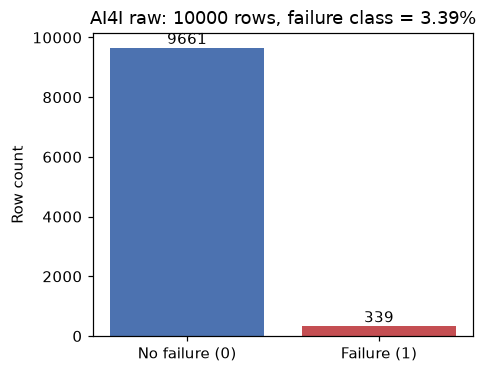

Target
0    9661
1     339
Name: count, dtype: int64
Minority class ratio (Target=1): 3.39%


In [21]:
counts_raw = raw["Target"].value_counts().sort_index()
pct_fail_raw = 100 * counts_raw[1] / counts_raw.sum()

fig, ax = plt.subplots(figsize=(4.5, 3.5))
bars = ax.bar(["No failure (0)", "Failure (1)"], counts_raw.values,
              color=["#4C72B0", "#C44E52"])
for b, v in zip(bars, counts_raw.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v}", ha="center", va="bottom")
ax.set_ylabel("Row count")
ax.set_title(f"AI4I raw: {len(raw)} rows, failure class = {pct_fail_raw:.2f}%")
plt.tight_layout()
plt.show()

print(counts_raw)
print(f"Minority class ratio (Target=1): {pct_fail_raw:.2f}%")

## 1. Angle encoding — before and after

`load_binary_dataset` turns the 5 numeric columns + `Type` (3-column one-hot)
into an 8-dimensional vector, then scales each dimension to `[0, pi]` (fit on
the training split) to use as RX/RY rotation angles in the VQC. With
`n_qubits=8` (= 8 native features), this step is a 1-to-1 mapping (no
PCA/no padding), so each feature can be compared directly to its angle.

In [22]:
num_cols = ["Air temperature [K]", "Process temperature [K]",
            "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
type_oh_cols = sorted(raw["Type"].unique())  # matches pd.get_dummies' default order (L,M,H)
feature_names = num_cols + [f"Type={t}" for t in type_oh_cols]

X_raw_full = np.hstack([raw[num_cols].to_numpy(float),
                         pd.get_dummies(raw["Type"]).to_numpy(float)])
print("8 feature names (in the same order as dataset.py):")
for i, n in enumerate(feature_names):
    print(f"  qubit {i}: {n}")

8 feature names (in the same order as dataset.py):
  qubit 0: Air temperature [K]
  qubit 1: Process temperature [K]
  qubit 2: Rotational speed [rpm]
  qubit 3: Torque [Nm]
  qubit 4: Tool wear [min]
  qubit 5: Type=H
  qubit 6: Type=L
  qubit 7: Type=M


In [23]:
# Data that HAS gone through angle encoding (scaled to [0,pi]) but NOT SMOTE yet
# -- used to compare 1-to-1 with a couple of raw rows above (same seed/split, but
# the train-split row order can differ from the raw file, so we read straight off
# the returned X_train rather than trying to match absolute row indices).
d_before = load_binary_dataset("predictive_maintenance", n_qubits=N_QUBITS,
                                max_samples=MAX_SAMPLES, seed=SEED, smote=False)
Xtr_before, ytr_before = d_before["X_train"], d_before["y_train"].astype(int)
print("X_train (before SMOTE) shape:", Xtr_before.shape)
print("min/max after scaling:", Xtr_before.min(), Xtr_before.max(), " (expected within [0, pi] =", np.pi, ")")

X_train (before SMOTE) shape: (140, 8)
min/max after scaling: 0.0 3.1415926535897967  (expected within [0, pi] = 3.141592653589793 )


In [24]:
# Side-by-side table: one class-0 sample and one class-1 sample, RAW value
# (real units) vs value AFTER angle-encoding (radians, [0,pi]). X_train has
# already been through split+scaling, so we illustrate using a raw row plus a
# scaler fit the same way dataset.py does (not tied to a specific post-split row
# index, since PCA/splitting break the 1-to-1 link to the raw dataframe when
# n_qubits < 8; here n_qubits=8 so there is NO PCA, only scaling -- we illustrate
# with one raw row and manually apply the same MinMax transform the pipeline uses).
from sklearn.preprocessing import MinMaxScaler
# Rebuilt exactly as dataset.py does, but stopped right before the split step --
# ONLY to obtain an illustrative scaler (not used for actual training).
type_oh_full = pd.get_dummies(raw["Type"]).to_numpy(float)
X_illustrate = np.hstack([raw[num_cols].to_numpy(float), type_oh_full])
scaler_illustrate = MinMaxScaler(feature_range=(0.0, np.pi)).fit(X_illustrate)

sample_idx = [raw.index[raw["Target"] == 0][0], raw.index[raw["Target"] == 1][0]]
table_rows = []
for idx in sample_idx:
    raw_vals = X_illustrate[idx]
    angle_vals = scaler_illustrate.transform(raw_vals.reshape(1, -1))[0]
    table_rows.append({"sample": f"row {idx} (Target={raw.loc[idx, 'Target']})",
                        **{f"{n} [raw]": round(v, 2) for n, v in zip(feature_names, raw_vals)}})
    table_rows.append({"sample": f"row {idx} -> RX/RY angle (rad)",
                        **{n: round(v, 3) for n, v in zip(feature_names, angle_vals)}})
pd.DataFrame(table_rows).set_index("sample")

,Air temperature [K] [raw],Process temperature [K] [raw],Rotational speed [rpm] [raw],Torque [Nm] [raw],Tool wear [min] [raw],Type=H [raw],Type=L [raw],Type=M [raw],Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type=H,Type=L,Type=M
sample,,,,,,,,,,,,,,,,
row 0 (Target=0),298.1,308.6,1551.0,42.8,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
row 0 -> RX/RY angle (rad),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.956,1.125,0.700,1.683,0.000,0.0,0.000,3.142
row 50 (Target=1),298.9,309.1,2861.0,4.6,143.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
row 50 -> RX/RY angle (rad),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.229,1.319,3.096,0.035,1.776,0.0,3.142,0.000


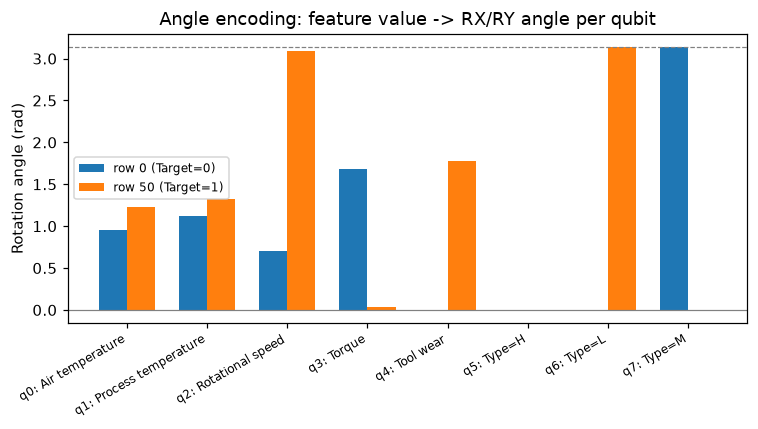

In [25]:
# Bar chart: the 8 rotation angles (radians) for the two samples above, on
# the same [0, pi] scale
angles_by_sample = []
labels = []
for idx in sample_idx:
    raw_vals = X_illustrate[idx]
    angle_vals = scaler_illustrate.transform(raw_vals.reshape(1, -1))[0]
    angles_by_sample.append(angle_vals)
    labels.append(f"row {idx} (Target={raw.loc[idx, 'Target']})")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(N_QUBITS)
w = 0.35
for i, (angs, lab) in enumerate(zip(angles_by_sample, labels)):
    ax.bar(x + (i - 0.5) * w, angs, width=w, label=lab)
ax.axhline(0, color="gray", lw=0.8)
ax.axhline(np.pi, color="gray", lw=0.8, ls="--")
ax.set_xticks(x, [f"q{i}: {n.split(' [')[0]}" for i, n in enumerate(feature_names)],
              fontsize=8, rotation=30, ha="right")
ax.set_ylabel("Rotation angle (rad)")
ax.set_ylim(-0.15, np.pi + 0.15)
ax.set_title("Angle encoding: feature value -> RX/RY angle per qubit")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

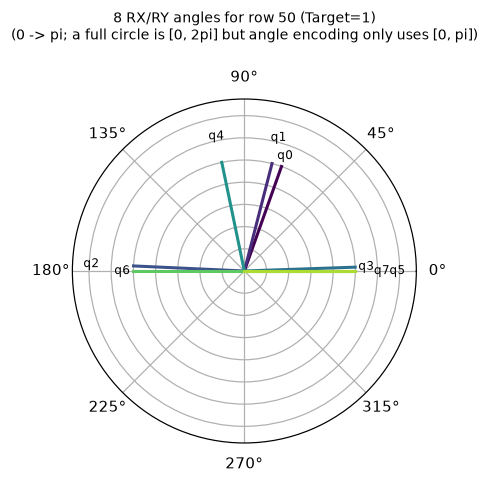

In [26]:
# Polar plot: visualize one sample's 8 angles as 8 clock hands on a unit
# circle -- an intuitive picture of "angle encoding" (rotation angle around
# the Bloch axis).
angs = angles_by_sample[1]  # the Target=1 sample
fig = plt.figure(figsize=(4.5, 4.5))
ax = fig.add_subplot(projection="polar")
for i, a in enumerate(angs):
    ax.plot([a, a], [0, 1], lw=2, color=plt.cm.viridis(i / N_QUBITS))
    label_r = 1.10 + 0.14 * (i % 3)  # stagger radius so overlapping angles don't collide
    ax.text(a, label_r, f"q{i}", ha="center", va="center", fontsize=8)
ax.set_ylim(0, 1.55)
ax.set_yticklabels([])
ax.set_title(f"8 RX/RY angles for {labels[1]}\n(0 -> pi; a full circle is [0, 2pi] but angle encoding only uses [0, pi])",
             fontsize=9, pad=20)
plt.tight_layout()
plt.show()

## 2. SMOTE — training data before and after

`X_train`/`y_train` are taken DIRECTLY from `load_binary_dataset(..., smote=False)`
(before) and `smote=True`, the default (after). `X_val` is unchanged in both
cases — SMOTE only ever touches the training split; val/test keep the true
imbalance ratio (see memory note `ai4i-smote-fix`).

In [27]:
d_after = load_binary_dataset("predictive_maintenance", n_qubits=N_QUBITS,
                               max_samples=MAX_SAMPLES, seed=SEED, smote=True)
Xtr_after, ytr_after = d_after["X_train"], d_after["y_train"].astype(int)

n_before = len(ytr_before)
summary = pd.DataFrame({
    "n_train":     [len(ytr_before), len(ytr_after)],
    "class_0":     [(ytr_before == 0).sum(), (ytr_after == 0).sum()],
    "class_1":     [(ytr_before == 1).sum(), (ytr_after == 1).sum()],
    "% class_1":   [100*(ytr_before == 1).mean(), 100*(ytr_after == 1).mean()],
}, index=["before SMOTE", "after SMOTE"])
summary

,n_train,class_0,class_1,% class_1
before SMOTE,140,135,5,3.571429
after SMOTE,270,135,135,50.000000


In [28]:
# Verify how SMOTE concatenates its result: imblearn keeps ALL original
# samples UNCHANGED at the front of the array, and appends synthetic samples
# at the END -- lets us separate "original" from "synthetic".
same_prefix = np.allclose(Xtr_after[:n_before], Xtr_before)
print(f"n before SMOTE = {n_before}, n after SMOTE = {len(ytr_after)}, "
      f"synthetic samples added = {len(ytr_after) - n_before}")
print(f"Check: first {n_before} rows of X_after == X_before (unchanged): {same_prefix}")
assert same_prefix, "Assumption about SMOTE's output ordering is wrong -- check the imblearn version."
is_synthetic = np.zeros(len(ytr_after), dtype=bool)
is_synthetic[n_before:] = True

n before SMOTE = 140, n after SMOTE = 270, synthetic samples added = 130
Check: first 140 rows of X_after == X_before (unchanged): True


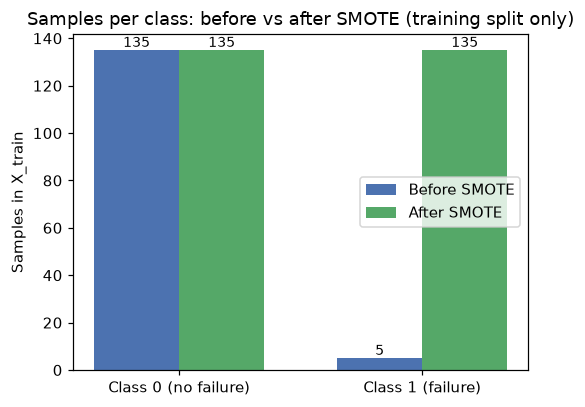

In [29]:
fig, ax = plt.subplots(figsize=(5, 3.8))
x = np.arange(2)
w = 0.35
before_counts = [(ytr_before == 0).sum(), (ytr_before == 1).sum()]
after_counts = [(ytr_after == 0).sum(), (ytr_after == 1).sum()]
b1 = ax.bar(x - w/2, before_counts, width=w, label="Before SMOTE", color="#4C72B0")
b2 = ax.bar(x + w/2, after_counts, width=w, label="After SMOTE", color="#55A868")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{int(b.get_height())}",
                ha="center", va="bottom", fontsize=9)
ax.set_xticks(x, ["Class 0 (no failure)", "Class 1 (failure)"])
ax.set_ylabel("Samples in X_train")
ax.set_title("Samples per class: before vs after SMOTE (training split only)")
ax.legend()
plt.tight_layout()
plt.show()

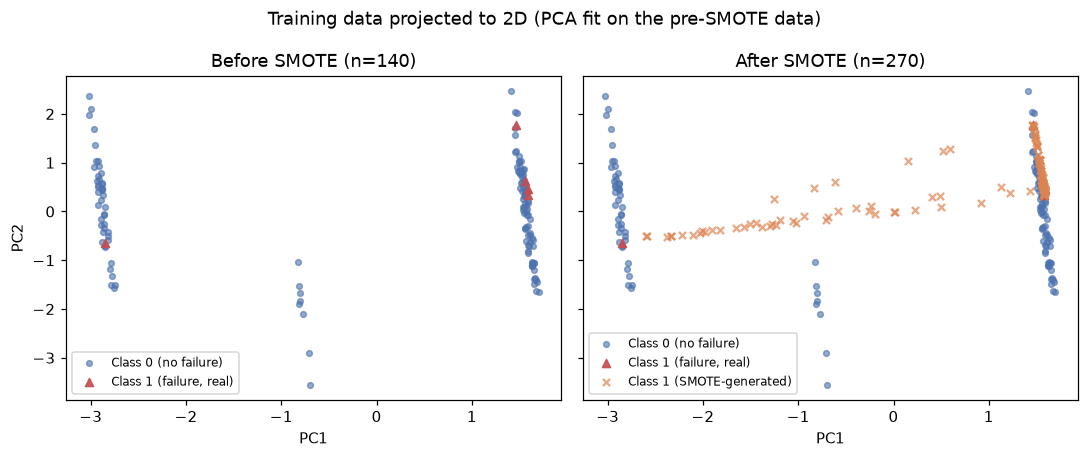

In [30]:
# Project to 2D with PCA (fit on the data BEFORE SMOTE) so both panels
# share the SAME projection -- a fair before/after comparison.
from sklearn.decomposition import PCA
p2 = PCA(n_components=2, random_state=SEED).fit(Xtr_before)
proj_before = p2.transform(Xtr_before)
proj_after = p2.transform(Xtr_after)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True, sharey=True)

ax = axes[0]
ax.scatter(proj_before[ytr_before==0,0], proj_before[ytr_before==0,1],
           s=14, alpha=0.6, label="Class 0 (no failure)", color="#4C72B0")
ax.scatter(proj_before[ytr_before==1,0], proj_before[ytr_before==1,1],
           s=28, alpha=0.9, label="Class 1 (failure, real)", color="#C44E52", marker="^")
ax.set_title(f"Before SMOTE (n={len(ytr_before)})")
ax.legend(fontsize=8)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

ax = axes[1]
orig_mask = ~is_synthetic
ax.scatter(proj_after[orig_mask & (ytr_after==0),0], proj_after[orig_mask & (ytr_after==0),1],
           s=14, alpha=0.6, label="Class 0 (no failure)", color="#4C72B0")
ax.scatter(proj_after[orig_mask & (ytr_after==1),0], proj_after[orig_mask & (ytr_after==1),1],
           s=28, alpha=0.9, label="Class 1 (failure, real)", color="#C44E52", marker="^")
ax.scatter(proj_after[is_synthetic,0], proj_after[is_synthetic,1],
           s=22, alpha=0.7, label="Class 1 (SMOTE-generated)", color="#DD8452", marker="x")
ax.set_title(f"After SMOTE (n={len(ytr_after)})")
ax.legend(fontsize=8)
ax.set_xlabel("PC1")

fig.suptitle("Training data projected to 2D (PCA fit on the pre-SMOTE data)")
plt.tight_layout()
plt.show()

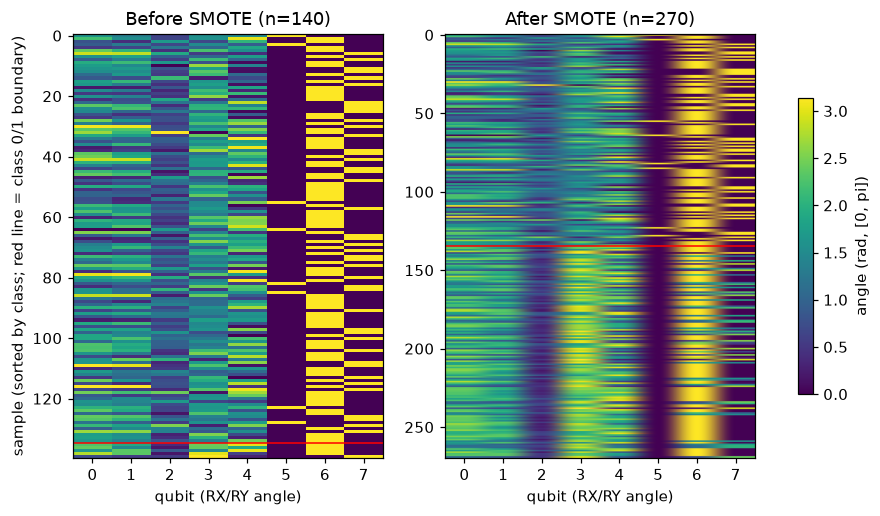

In [31]:
# Heatmap: the full X_train (8 native/qubit columns) before vs after SMOTE,
# rows sorted by class, to see the "shape" of the table change (far more
# class-1 rows after SMOTE).
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, X, y, title in [
    (axes[0], Xtr_before, ytr_before, f"Before SMOTE (n={len(ytr_before)})"),
    (axes[1], Xtr_after, ytr_after, f"After SMOTE (n={len(ytr_after)})"),
]:
    order = np.argsort(y, kind="stable")
    im = ax.imshow(X[order], aspect="auto", cmap="viridis", vmin=0, vmax=np.pi)
    n0 = (y == 0).sum()
    ax.axhline(n0 - 0.5, color="red", lw=1)
    ax.set_title(title)
    ax.set_xlabel("qubit (RX/RY angle)")
    ax.set_xticks(range(N_QUBITS))
axes[0].set_ylabel("sample (sorted by class; red line = class 0/1 boundary)")
fig.colorbar(im, ax=axes, shrink=0.7, label="angle (rad, [0, pi])")
plt.show()

## 3. Summary

- **Angle encoding**: the 8 native features (5 numeric, in wildly different
  physical units — Kelvin, rpm, Nm, minutes — plus 3 one-hot `Type` columns)
  are brought onto a common `[0, pi]` scale by `MinMaxScaler` to serve as
  RX/RY rotation angles for the 8-qubit VQC. With `n_qubits=8` this is a
  1-to-1 mapping (no PCA/no padding).
- **SMOTE**: applied AFTER the scaling/angle-encoding step, ONLY on
  `X_train` — it generates minority-class (machine-failure) samples by
  interpolating between same-class neighbours directly in that `[0,pi]`
  space (so synthetic samples land inside `[0,pi]` naturally, no clipping
  needed). `X_val`/`X_test` keep the true imbalance ratio (~3.4%) for honest
  evaluation.
- Compared with the old approach (undersampling the majority class down to
  the minority count): undersampling kept only 339×2=678 rows out of the
  full 10,000 (discarding ~96% of real data); SMOTE keeps all real data and
  only *adds* synthetic data to the training split.
